# 12 — Terrain Transition Detection Analysis

## Motivation

Standard classification metrics (accuracy, macro-F1) treat every 2-second window equally. For a mobile robot navigating variable terrain, *temporal* performance matters: how quickly after a ground-truth terrain change does the classifier commit to the new class?

A model that detects a transition from grass to muddy dirt within 3 seconds allows the controller to adapt before wheel slip occurs. One that takes 50 seconds — or never detects it — provides no useful early warning.

This notebook quantifies **transition detection latency** for all six classifiers trained in earlier notebooks, using **tuned** hyperparameters throughout to ensure the comparison reflects each model's best achievable behaviour.

## Methodology

- **Data**: `dataset_A_pruned_5run.csv` — 2,346 windows (2 s duration, 1 s step, 5 runs). 123 hand-crafted IMU + odometry features covering statistical moments, spectral energy, autocorrelation, and cross-channel correlations.
- **Raw windows**: `raw_windows_cnn.parquet` — 5 IMU channels (ax, ay, az, gx, gz) at 100 Hz for the CNN. gy/yaw excluded as it encodes steering geometry rather than terrain texture.
- **Models evaluated**:
  - Classical (sklearn Pipelines): LogisticRegression, RandomForest, XGBoost, SVM — with **tuned** hyperparameters from `results/tuning_best_params.json`.
  - MLP: 3-layer [256, 128, 64] perceptron — best configuration from `results/mlp_metrics_summary.csv`.
  - CNN: 1D convolutional network [32, 64, 128 filters] — **best** hyperparameters from `results/cnn/cnn_hp_tuning_summary.csv` (dropout=0.5, batch_size=64, macro_f1_mean=0.7628).
- **Evaluation protocol**: Leave-One-Run-Out (LORO) cross-validation. For each of the 5 runs, the model is trained on the remaining 4 and predicts every window in the held-out run. No data leakage.

## Stability Criterion

A transition is counted as **detected** only when the classifier produces `N_STABLE` **consecutive** windows all predicting the new terrain class. At a 1-second window step, `N_STABLE=3` corresponds to a 3-second confirmation window.

- **Detected**: stable run of ≥ N_STABLE correct predictions found within the current terrain epoch.
- **Missed**: no stable run found before the next ground-truth transition.
- **Boundary**: too few windows remain at the end of the run to satisfy N_STABLE.

Detection delay = time of the first window in the stable run − ground-truth transition time. The minimum possible delay is N_STABLE × step_size = 3 seconds.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------------------
# Project root bootstrap
# ---------------------------------------------------------------------------
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.transition import (
    # Prediction generation
    run_classical_loro_cv,
    run_mlp_loro_cv,
    run_cnn_loro_cv,
    # Analysis
    detect_gt_transitions,
    analyze_transitions,
    compare_models,
    # Visualization
    plot_transition_timeline,
    plot_detection_delay_histogram,
    # Constants
    LABEL_ORDER,
    TERRAIN_COLORS,
    ID_COLS,
)

# ---------------------------------------------------------------------------
# Global style
# ---------------------------------------------------------------------------
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Experiment parameters
# ---------------------------------------------------------------------------
RANDOM_STATE  = 42
N_STABLE      = 3      # consecutive windows required for a stable detection
THRESHOLD_SEC = 10.0   # delays > this are flagged 'late'

LABEL_COL = "label"
RUN_COL   = "run_id"

# ---------------------------------------------------------------------------
# Load tuned hyperparameters for classical models
# Produced by 08_base_tuning.ipynb, stored in results/tuning_best_params.json
# Keys use sklearn Pipeline format: clf__<param_name>
# ---------------------------------------------------------------------------
TUNING_PARAMS_PATH = RESULTS_DIR / "tuning_best_params.json"
with open(TUNING_PARAMS_PATH) as f:
    BEST_PARAMS = json.load(f)

print("Tuned hyperparameters loaded:")
for model, params in BEST_PARAMS.items():
    print(f"  {model}: {params}")

# ---------------------------------------------------------------------------
# CNN best configuration
# Rank-1 from results/cnn/cnn_hp_tuning_summary.csv
#   filters=[32,64,128], kernels=[7,5,3], dropout=0.5, lr=1e-3, batch_size=64
#   macro_f1_mean=0.7628 vs 0.7487 for the previous dropout=0.3/batch=32 config
# ---------------------------------------------------------------------------
CNN_FILTERS      = [32, 64, 128]
CNN_KERNELS      = [7, 5, 3]
CNN_DROPOUT      = 0.5    # best from HP tuning (was 0.3)
CNN_BATCH_SIZE   = 64     # best from HP tuning (was 32)
CNN_LR           = 1e-3
CNN_WEIGHT_DECAY = 1e-4

print(f"\nCNN best config: filters={CNN_FILTERS}, kernels={CNN_KERNELS}, "
      f"dropout={CNN_DROPOUT}, batch_size={CNN_BATCH_SIZE}, lr={CNN_LR}")

print("\nSetup complete.")
print(f"  Project root : {PROJECT_ROOT}")
print(f"  N_STABLE     : {N_STABLE} windows  (min detection delay = {N_STABLE}s)")
print(f"  THRESHOLD    : {THRESHOLD_SEC} s")

Tuned hyperparameters loaded:
  LogisticRegression: {'clf__C': 0.1}
  RandomForest: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}
  XGBoost: {'clf__subsample': 1.0, 'clf__n_estimators': 500, 'clf__max_depth': 6, 'clf__learning_rate': 0.2}
  SVM: {'clf__gamma': 'scale', 'clf__C': 0.1}

CNN best config: filters=[32, 64, 128], kernels=[7, 5, 3], dropout=0.5, batch_size=64, lr=0.001

Setup complete.
  Project root : /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis
  N_STABLE     : 3 windows  (min detection delay = 3s)
  THRESHOLD    : 10.0 s


## 1. Load Data

In [2]:
# ---------------------------------------------------------------------------
# Feature dataset (classical models + MLP)
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_DIR / "dataset_A_pruned_5run.csv")
feature_cols = [c for c in df.columns if c not in ID_COLS]
run_ids = sorted(df[RUN_COL].unique().tolist())

print(f"Feature dataset : {len(df)} windows, {len(feature_cols)} features, {len(run_ids)} runs")
print(f"Runs            : {run_ids}")
print(f"Label counts    :")
print(df[LABEL_COL].value_counts().to_string())
print()

# ---------------------------------------------------------------------------
# Raw-window dataset (CNN only)
# ---------------------------------------------------------------------------
cnn_parquet = DATA_DIR / "raw_windows_cnn.parquet"
cnn_df = pd.read_parquet(cnn_parquet)
print(f"CNN raw windows : {len(cnn_df)} windows")
series_cols = [c for c in cnn_df.columns if c.endswith("__series")]
print(f"Series columns  : {series_cols}")

Feature dataset : 2346 windows, 123 features, 5 runs
Runs            : ['log_20260223_142511.490', 'log_20260226_102148.990', 'log_20260309_141435.414_partA', 'log_20260309_141435.414_partB', 'log_20260326_120021.508']
Label counts    :
label
smooth_terrain      706
dry_dirt_track      652
grass               488
cobblestone         355
muddy_dirt_track    145

CNN raw windows : 2346 windows
Series columns  : ['ax__series', 'ay__series', 'az__series', 'gx__series', 'gz__series']


## 2. Ground-Truth Transition Inventory

Before running any model, we identify every terrain label change in the dataset. Each run is sorted by `t_start` and scanned for consecutive windows where the label changes. This gives a fixed set of **12 ground-truth transitions** across 5 runs — the evaluation set all models are measured against.

Note: transitions are run-local. A label change spanning a run boundary (e.g. end of `partA` / start of `partB` of the same recording) is not counted, as the LORO-CV fold boundary falls there.

In [3]:
gt_transition_rows = []

for run_id in run_ids:
    run_df = (
        df[df[RUN_COL] == run_id]
        .sort_values("t_start")
        .rename(columns={"t_start": "time", LABEL_COL: "true_label"})
        .reset_index(drop=True)
    )
    transitions = detect_gt_transitions(run_df, time_col="time", true_col="true_label")
    for t in transitions:
        t["run_id"] = run_id
    gt_transition_rows.extend(transitions)

gt_df = pd.DataFrame(gt_transition_rows)[["run_id", "from_label", "to_label", "gt_time"]]

print(f"Total ground-truth transitions across all runs: {len(gt_df)}")
print()
print(gt_df.to_string(index=False))

Total ground-truth transitions across all runs: 12

                       run_id     from_label         to_label  gt_time
      log_20260223_142511.490          grass   smooth_terrain   511.19
      log_20260223_142511.490 smooth_terrain muddy_dirt_track   711.74
      log_20260226_102148.990          grass   smooth_terrain   642.58
      log_20260226_102148.990 smooth_terrain muddy_dirt_track   982.29
log_20260309_141435.414_partA          grass   smooth_terrain   414.06
log_20260309_141435.414_partA smooth_terrain   dry_dirt_track   649.28
log_20260309_141435.414_partB dry_dirt_track            grass  1852.06
log_20260309_141435.414_partB          grass   smooth_terrain  2392.06
log_20260309_141435.414_partB smooth_terrain      cobblestone  2461.74
log_20260309_141435.414_partB    cobblestone   smooth_terrain  2627.06
      log_20260326_120021.508          grass   smooth_terrain   533.10
      log_20260326_120021.508 smooth_terrain      cobblestone  1147.39


## 3. Generate Per-Window Predictions (LORO-CV)

Each model is evaluated under strict Leave-One-Run-Out cross-validation. The model sees **zero** windows from the test run during training.

**Hyperparameter provenance** (all sourced from earlier notebooks):
- **Classical models**: tuned params loaded from `results/tuning_best_params.json` (notebook `08_base_tuning.ipynb`). Key changes vs. defaults: LR C=0.1 (was 1.0), RF max_depth=10 + n_estimators=200 (was None/300), XGBoost n_estimators=500 + lr=0.2 + subsample=1.0 (were 300/0.1/0.8), SVM C=0.1 (was 1.0).
- **MLP**: hidden=[256, 128, 64], dropout=0.3, lr=1e-3 — best configuration from `results/mlp_metrics_summary.csv`.
- **CNN**: filters=[32,64,128], kernels=[7,5,3], **dropout=0.5, batch_size=64** — rank-1 config from `results/cnn/cnn_hp_tuning_summary.csv` (macro_f1_mean=0.7628 vs 0.7487 for prior dropout=0.3/batch=32 config).

**Runtime**: classical models ~1 min, MLP ~2–4 min, CNN ~4–8 min on CPU; much faster on CUDA.

In [4]:
# ---------------------------------------------------------------------------
# Classical models — using tuned hyperparameters from results/tuning_best_params.json
# ---------------------------------------------------------------------------
CLASSICAL_MODELS = ["RandomForest", "XGBoost", "LogisticRegression", "SVM"]

predictions: dict[str, pd.Series] = {}

for model_name in CLASSICAL_MODELS:
    print(f"Running tuned LORO-CV for {model_name}...")
    df_pred = run_classical_loro_cv(
        df=df,
        feature_cols=feature_cols,
        label_col=LABEL_COL,
        run_col=RUN_COL,
        model_name=model_name,
        imbalance="balanced",
        random_state=RANDOM_STATE,
        best_params=BEST_PARAMS,  # tuned hyperparameters from 08_base_tuning.ipynb
    )
    predictions[model_name] = df_pred["pred_label"]
    acc = (predictions[model_name] == df[LABEL_COL]).mean()
    print(f"  {model_name}: overall LORO-CV accuracy = {acc:.3f}")

print("\nClassical models done (using tuned hyperparameters).")

Running tuned LORO-CV for RandomForest...
  RandomForest: overall LORO-CV accuracy = 0.734
Running tuned LORO-CV for XGBoost...
  XGBoost: overall LORO-CV accuracy = 0.738
Running tuned LORO-CV for LogisticRegression...
  LogisticRegression: overall LORO-CV accuracy = 0.740
Running tuned LORO-CV for SVM...
  SVM: overall LORO-CV accuracy = 0.674

Classical models done (using tuned hyperparameters).


In [5]:
# ---------------------------------------------------------------------------
# MLP  (~1–3 min)
# ---------------------------------------------------------------------------
print("Running LORO-CV for MLP (this may take a few minutes)...")
df_mlp = run_mlp_loro_cv(
    df=df,
    feature_cols=feature_cols,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    hidden_dims=[256, 128, 64],
    dropout_rate=0.3,
    batch_size=32,
    max_epochs=200,
    patience=20,
    learning_rate=1e-3,
    weight_decay=1e-4,
    random_state=RANDOM_STATE,
)
predictions["MLP"] = df_mlp["pred_label"]
acc = (predictions["MLP"] == df[LABEL_COL]).mean()
print(f"  MLP: overall LORO-CV accuracy = {acc:.3f}")

Running LORO-CV for MLP (this may take a few minutes)...
  MLP fold log_20260223_142511.490: acc=0.700
  MLP fold log_20260226_102148.990: acc=0.828
  MLP fold log_20260309_141435.414_partA: acc=0.858
  MLP fold log_20260309_141435.414_partB: acc=0.860
  MLP fold log_20260326_120021.508: acc=0.457
  MLP: overall LORO-CV accuracy = 0.738


In [6]:
# ---------------------------------------------------------------------------
# CNN — best hyperparameters from results/cnn/cnn_hp_tuning_summary.csv
# Rank-1: filters=[32,64,128], kernels=[7,5,3], dropout=0.5, batch_size=64
# ---------------------------------------------------------------------------
print("Running tuned LORO-CV for CNN (this may take several minutes)...")
df_cnn = run_cnn_loro_cv(
    feature_df=df,
    cnn_df=cnn_df,
    label_col=LABEL_COL,
    run_col=RUN_COL,
    filters=CNN_FILTERS,          # [32, 64, 128]
    kernels=CNN_KERNELS,          # [7, 5, 3]
    dropout_rate=CNN_DROPOUT,     # 0.5 (best from HP tuning, was 0.3)
    batch_size=CNN_BATCH_SIZE,    # 64  (best from HP tuning, was 32)
    max_epochs=100,
    patience=15,
    learning_rate=CNN_LR,
    weight_decay=CNN_WEIGHT_DECAY,
    random_state=RANDOM_STATE,
)
predictions["CNN"] = df_cnn["pred_label"]
acc = (predictions["CNN"] == df[LABEL_COL]).mean()
print(f"  CNN: overall LORO-CV accuracy = {acc:.3f}")

Running tuned LORO-CV for CNN (this may take several minutes)...
  CNN fold log_20260223_142511.490: acc=0.638
  CNN fold log_20260226_102148.990: acc=0.869
  CNN fold log_20260309_141435.414_partA: acc=0.834
  CNN fold log_20260309_141435.414_partB: acc=0.819
  CNN fold log_20260326_120021.508: acc=0.450
  CNN: overall LORO-CV accuracy = 0.713


## 4. Transition Analysis

For each model, `compare_models()` searches every ground-truth transition and measures the detection delay. The `n_stable=3` criterion means the model must produce three **consecutive** windows predicting the new terrain class before the transition is counted as detected.

The search is bounded to the current terrain epoch (between successive ground-truth transitions). A correct prediction after the next transition is not credited to an earlier one — this prevents artificially low delays from models that oscillate for a long time before accidentally satisfying the stability criterion.

In [7]:
combined_transitions = compare_models(
    df=df,
    predictions_dict=predictions,
    time_col="t_start",
    true_col=LABEL_COL,
    run_col=RUN_COL,
    n_stable=N_STABLE,
    threshold_sec=THRESHOLD_SEC,
)

print(f"Total transition records: {len(combined_transitions)}")
print(f"  (= {len(gt_df)} GT transitions × {len(predictions)} models)")
print()

model_names = list(predictions.keys())
print(f"{'Model':<22}  {'Detected':>8}  {'Missed':>6}  {'Boundary':>8}  {'Det. Rate':>10}  {'Mean Delay':>10}  {'Median Delay':>12}")
print("-" * 80)
for model_name in model_names:
    sub = combined_transitions[combined_transitions["model"] == model_name]
    det   = sub[sub["outcome"] == "detected"]
    miss  = sub[sub["outcome"] == "missed"]
    bnd   = sub[sub["outcome"] == "boundary"]
    eff   = len(sub) - len(bnd)
    rate  = len(det) / eff if eff > 0 else float("nan")
    mean_d  = det["detection_delay_sec"].mean()
    med_d   = det["detection_delay_sec"].median()
    print(f"{model_name:<22}  {len(det):>8}  {len(miss):>6}  {len(bnd):>8}  "
          f"{rate:>10.1%}  {mean_d:>10.2f}s  {med_d:>12.2f}s")

Total transition records: 72
  (= 12 GT transitions × 6 models)

Model                   Detected  Missed  Boundary   Det. Rate  Mean Delay  Median Delay
--------------------------------------------------------------------------------
RandomForest                  10       2         0       83.3%        1.21s          0.00s
XGBoost                       12       0         0      100.0%       47.35s          0.52s
LogisticRegression            12       0         0      100.0%       47.47s          0.00s
SVM                           11       1         0       91.7%       50.65s          0.00s
MLP                           10       2         0       83.3%        1.02s          0.00s
CNN                           12       0         0      100.0%       49.74s          0.00s


In [8]:
# ---------------------------------------------------------------------------
# Full transition table
# ---------------------------------------------------------------------------
display_cols = [
    "model", "run_id", "from_label", "to_label",
    "gt_time", "detection_delay_sec", "outcome", "is_late",
]

styled = (
    combined_transitions[display_cols]
    .sort_values(["run_id", "gt_time", "model"])
    .style
    .format({"gt_time": "{:.1f}", "detection_delay_sec": "{:.2f}"})
    .map(
        lambda v: "background-color: #ffe0e0" if v == "missed"
        else ("background-color: #fff3cd" if v == "boundary" else ""),
        subset=["outcome"],
    )
)

styled

,model,run_id,from_label,to_label,gt_time,detection_delay_sec,outcome,is_late
60,CNN,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
24,LogisticRegression,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
48,MLP,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
0,RandomForest,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
36,SVM,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
12,XGBoost,log_20260223_142511.490,grass,smooth_terrain,511.2,0.00,detected,False
61,CNN,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,0.00,detected,False
25,LogisticRegression,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,0.00,detected,False
49,MLP,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,4.03,detected,False
1,RandomForest,log_20260223_142511.490,smooth_terrain,muddy_dirt_track,711.7,1.01,detected,False


## 5. Visualizations

### 5.1 Timeline Plots

Ground-truth (top band) vs. predicted (bottom band) terrain label over time for each run, shown for one model at a time.

Legend:
- **Dashed black lines**: ground-truth terrain transitions.
- **Solid green lines**: stable detections (delay ≤ threshold).
- **Solid orange lines**: late detections (delay > threshold).
- **Dotted red lines**: missed transitions (no stable detection found in the epoch).

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_timelines_randomforest.png


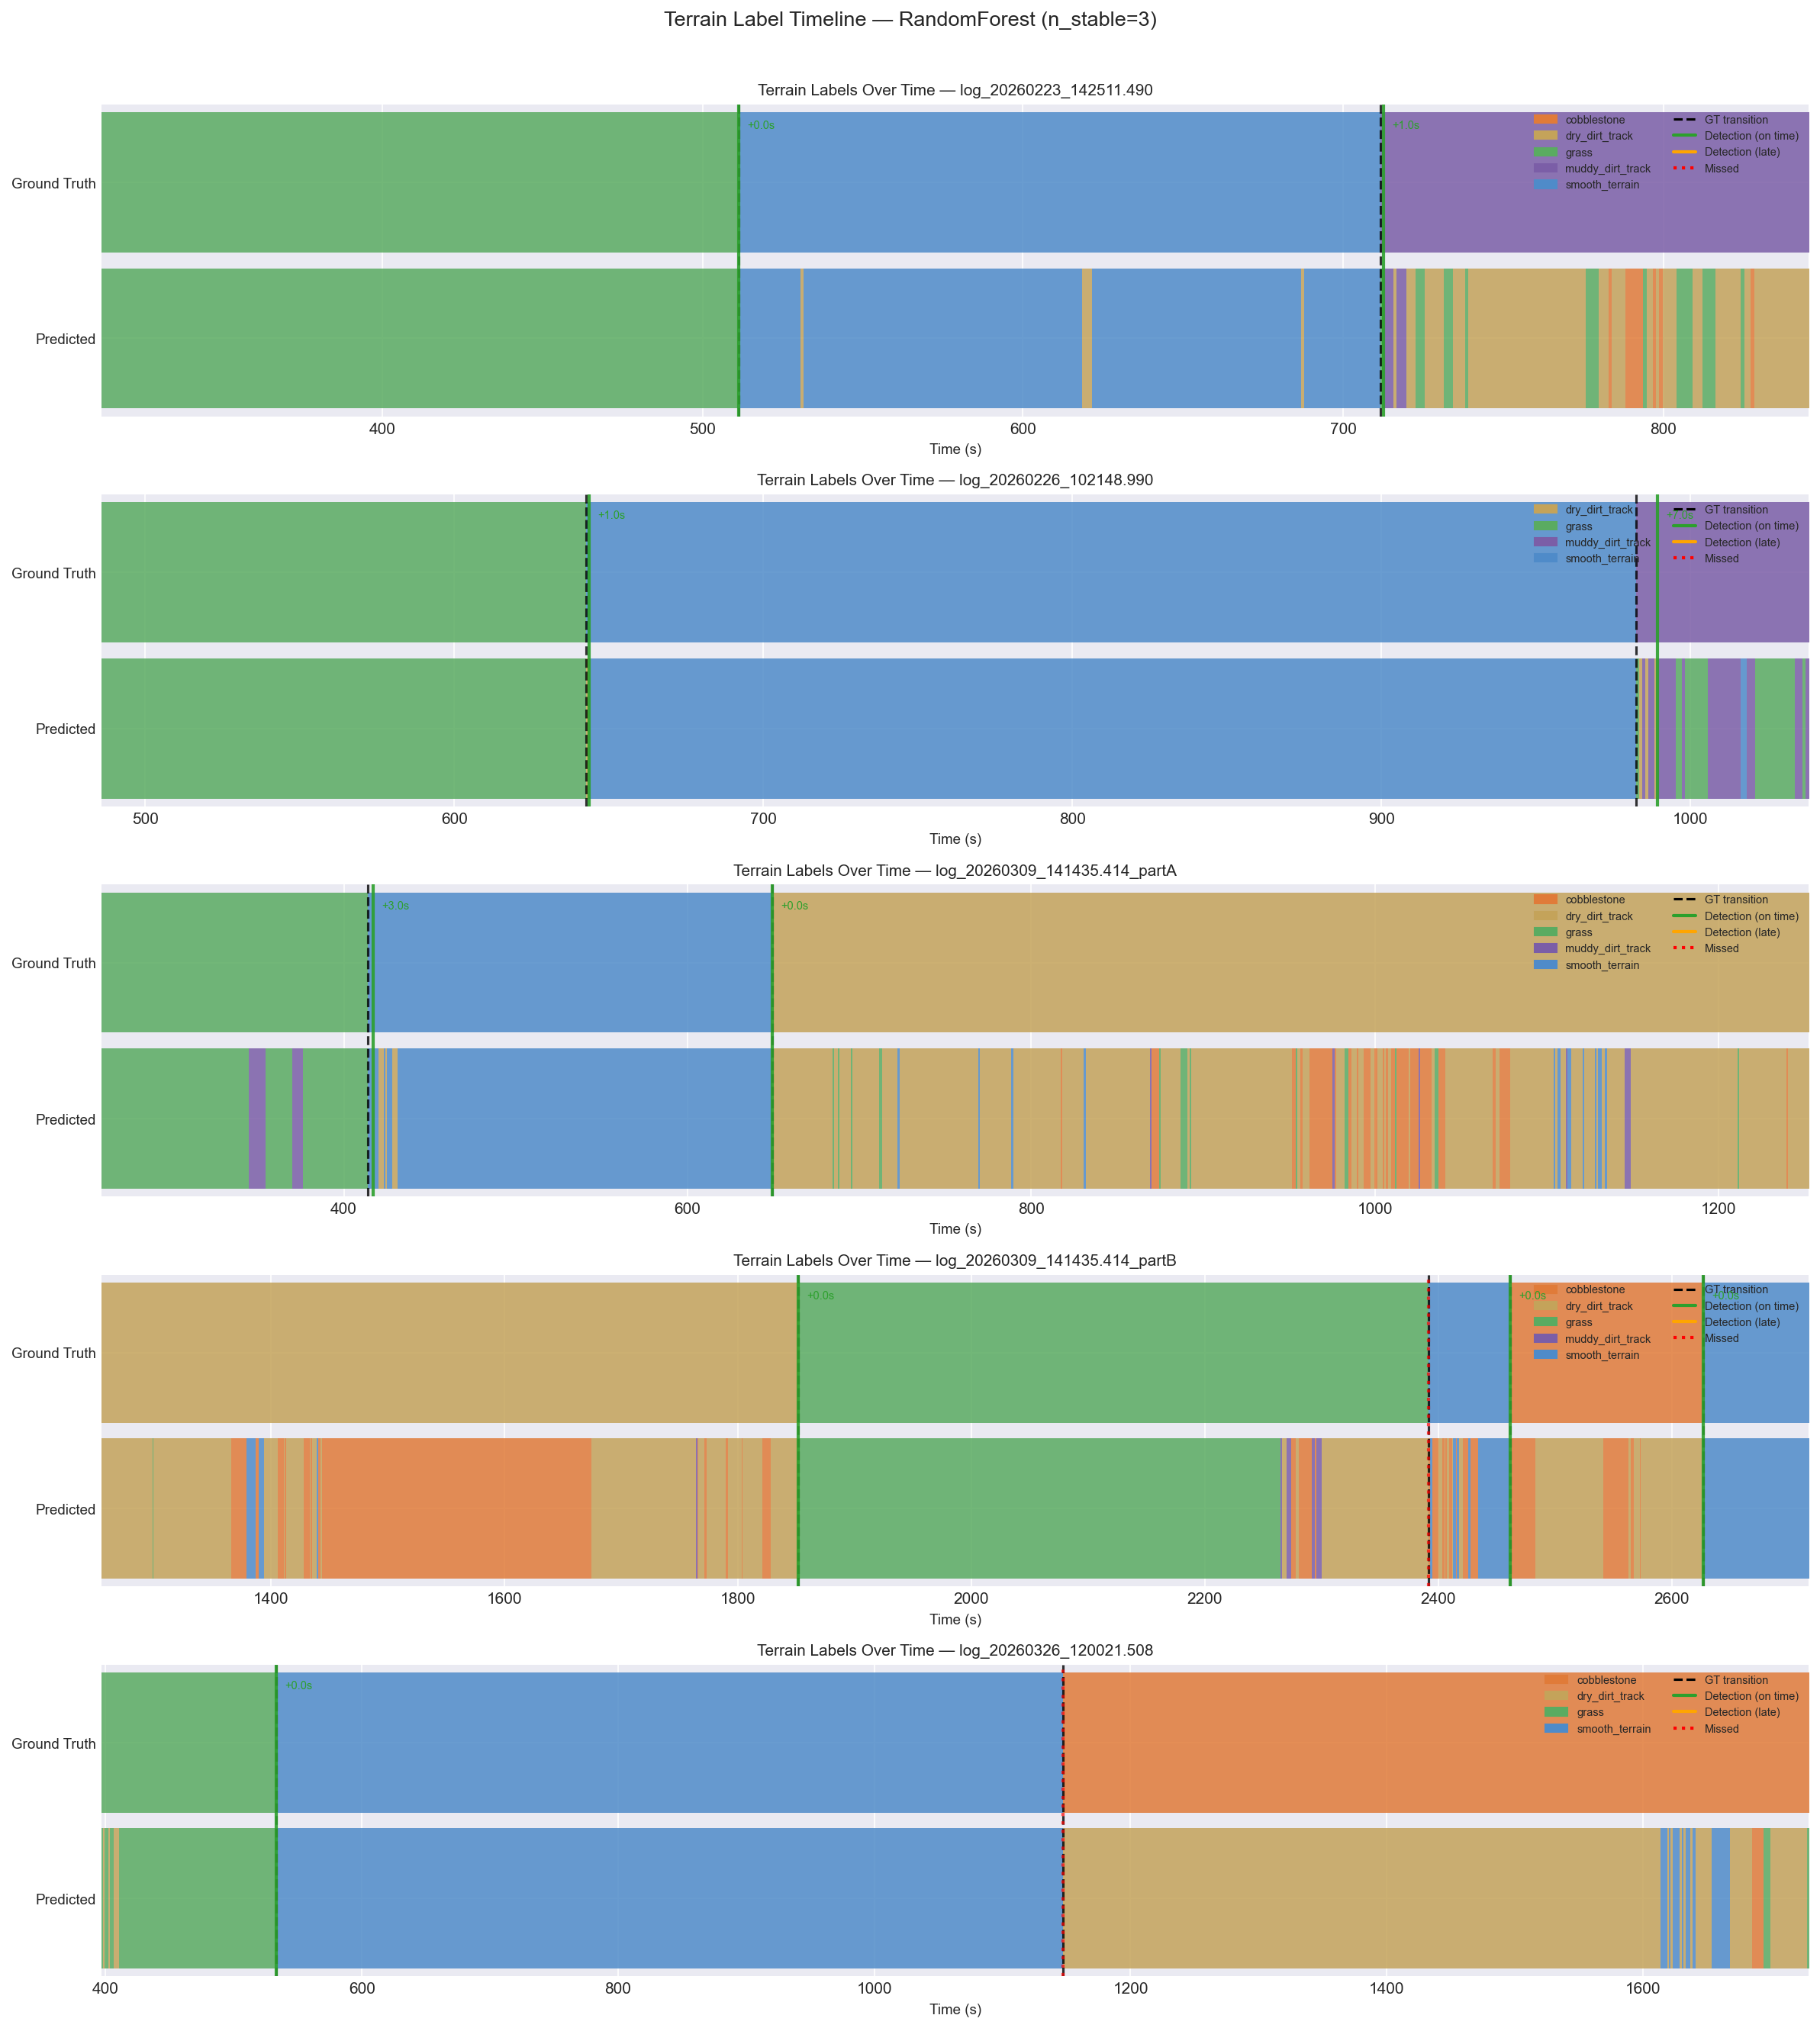

In [15]:
TIMELINE_MODEL = "RandomForest"  # change to any model in predictions

fig, axes = plt.subplots(
    len(run_ids), 1,
    figsize=(16, 3.5 * len(run_ids)),
    dpi=150,
)
if len(run_ids) == 1:
    axes = [axes]

for ax, run_id in zip(axes, run_ids):
    run_mask = df[RUN_COL] == run_id
    run_df = (
        df.loc[run_mask]
        .sort_values("t_start")
        .assign(
            time=lambda x: x["t_start"],
            true_label=lambda x: x[LABEL_COL],
            pred_label=predictions[TIMELINE_MODEL].loc[run_mask].values,
        )
        .reset_index(drop=True)
    )
    run_transitions = combined_transitions[
        (combined_transitions["run_id"] == run_id) &
        (combined_transitions["model"] == TIMELINE_MODEL)
    ]
    plot_transition_timeline(
        df=run_df,
        transitions_df=run_transitions,
        run_id=run_id,
        ax=ax,
        label_colors=TERRAIN_COLORS,
    )

fig.suptitle(
    f"Terrain Label Timeline — {TIMELINE_MODEL} (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
fig.tight_layout()
save_path = REPORTS_DIR / f"transition_timelines_{TIMELINE_MODEL.lower()}.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

### 5.2 Detection Delay Distributions

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_delay_histograms.png


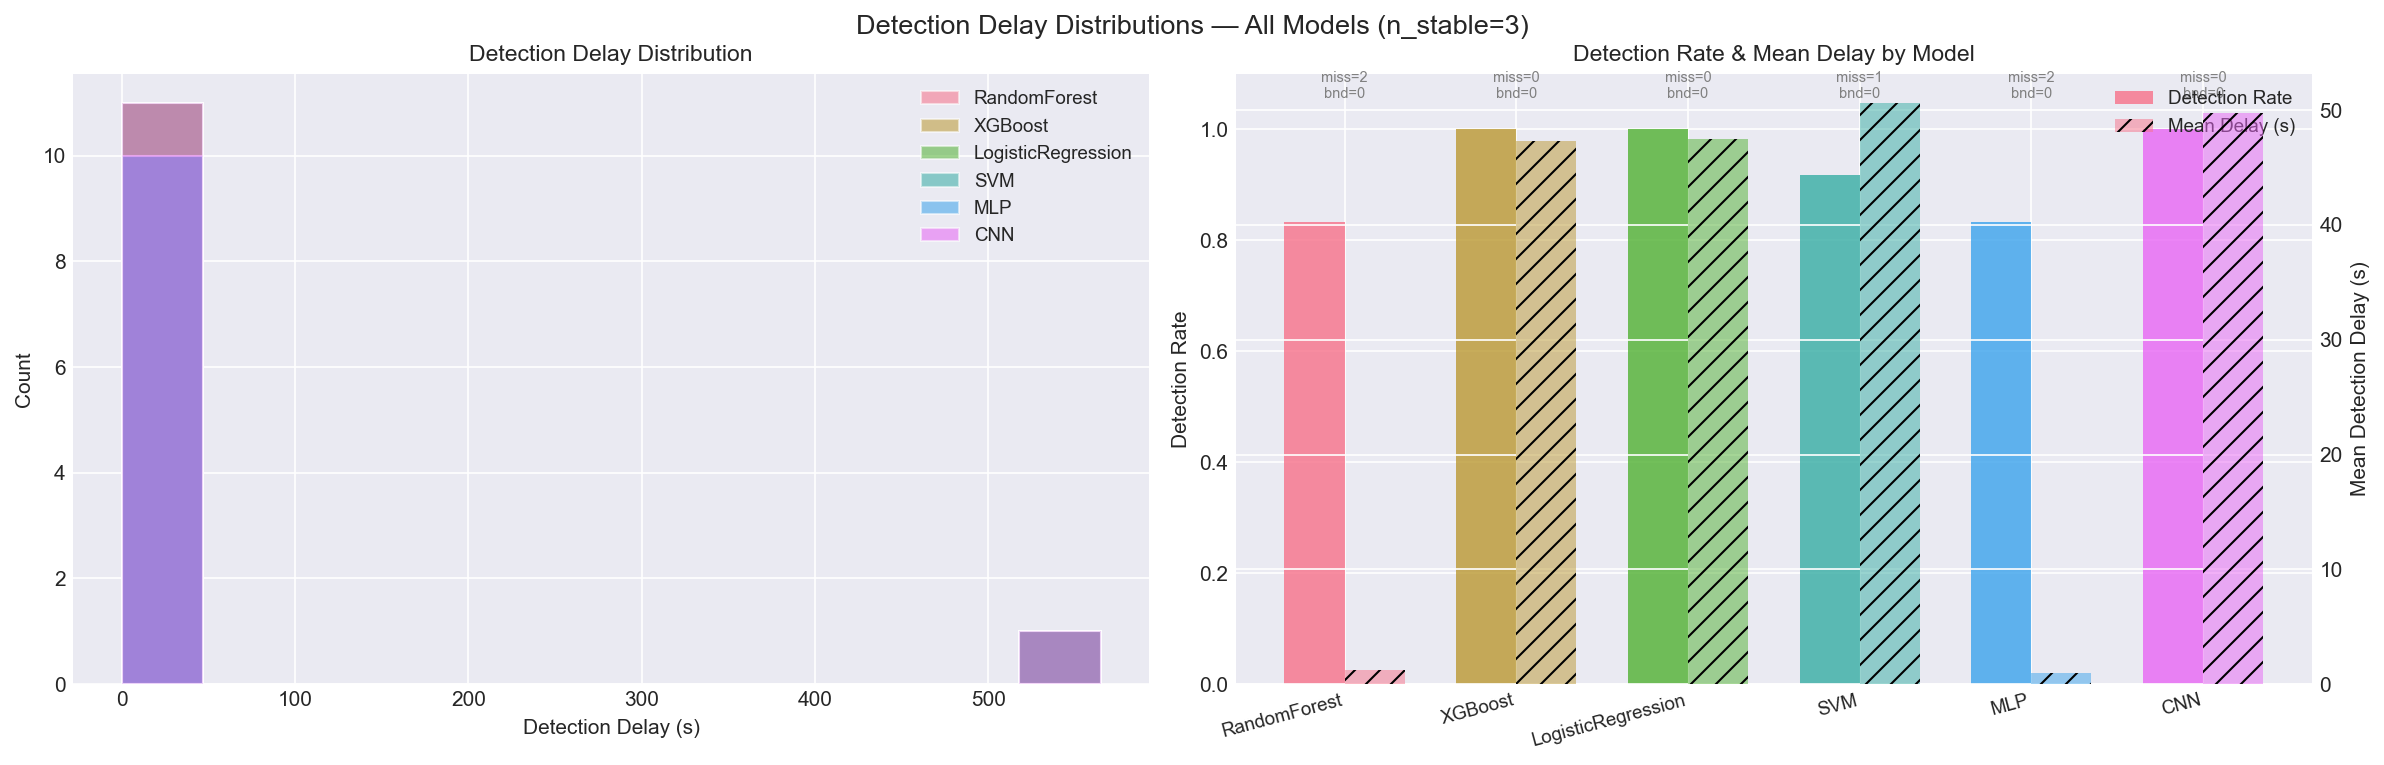

In [10]:
fig = plot_detection_delay_histogram(
    transitions_df=combined_transitions,
    bins=12,
    figsize=(16, 5),
)
fig.suptitle(
    f"Detection Delay Distributions — All Models (n_stable={N_STABLE})",
    fontsize=13, y=1.01,
)
save_path = REPORTS_DIR / "transition_delay_histograms.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 6. Sensitivity Analysis — Effect of `n_stable`

Higher `n_stable` values require the model to commit to the new class for longer before we count a detection. This trades robustness against noisy single-window predictions for higher mean delay and possibly more missed transitions.

The two panels below show:
- **Left**: how detection rate changes as `n_stable` increases — models that oscillate between classes (e.g. SVM) degrade quickly.
- **Right**: how mean detection delay grows — models that commit stably early (e.g. MLP) stay near the minimum even at `n_stable=7`.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_sensitivity_n_stable.png


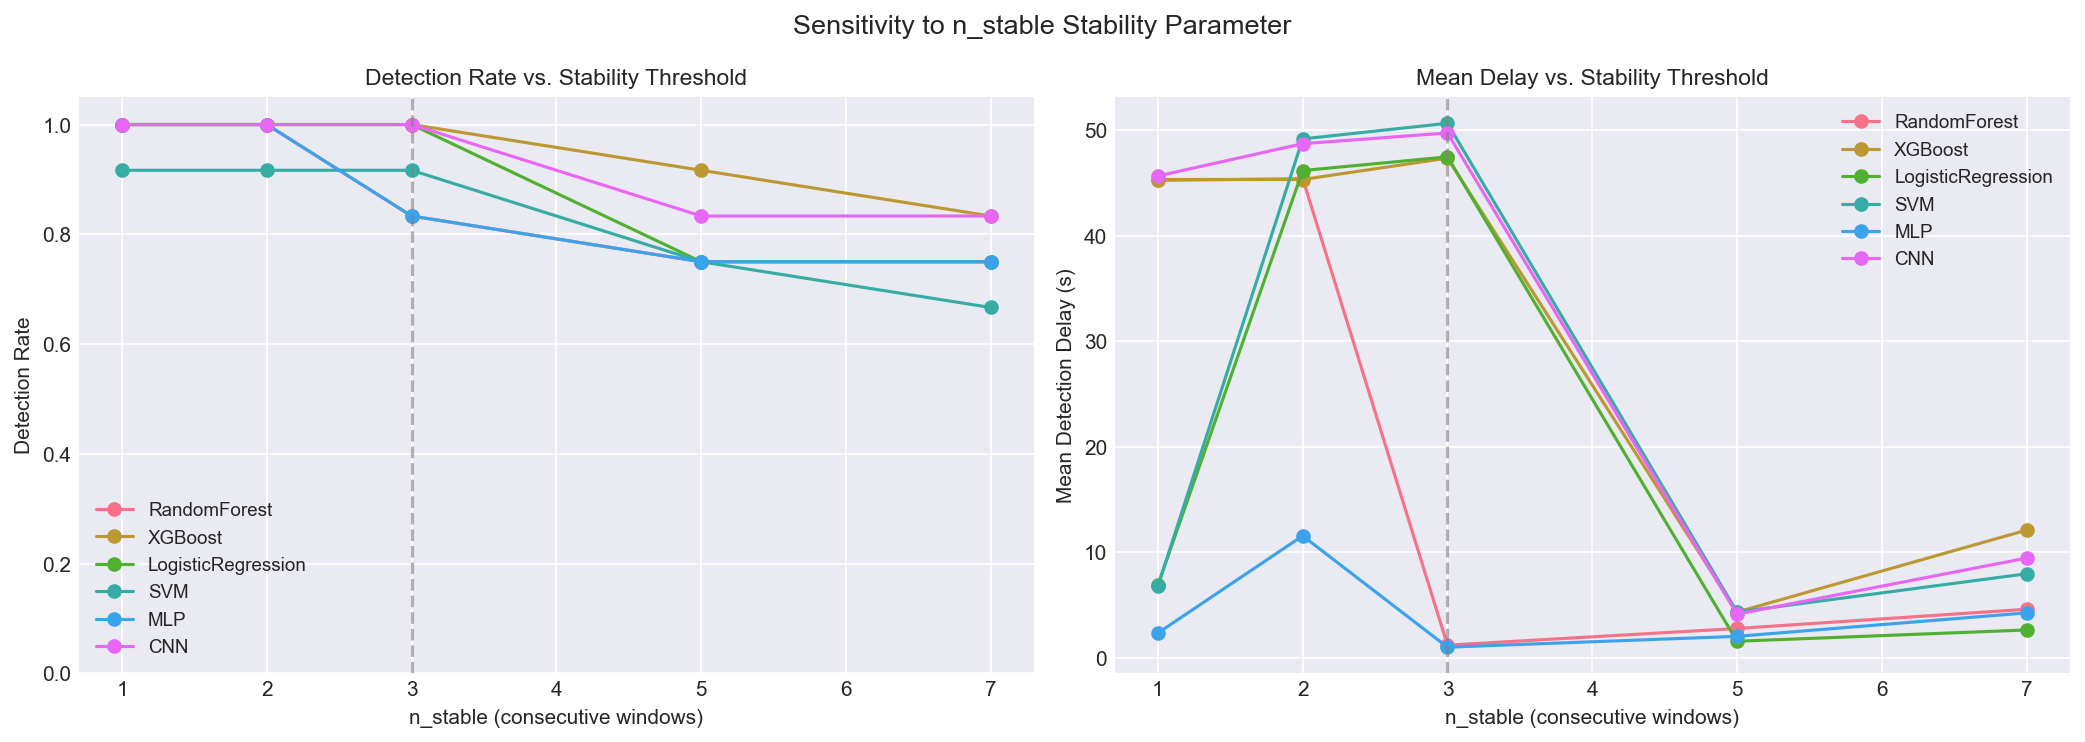

In [11]:
N_STABLE_VALUES = [1, 2, 3, 5, 7]
sensitivity_rows = []

for n_s in N_STABLE_VALUES:
    ct = compare_models(
        df=df,
        predictions_dict=predictions,
        time_col="t_start",
        true_col=LABEL_COL,
        run_col=RUN_COL,
        n_stable=n_s,
        threshold_sec=THRESHOLD_SEC,
    )
    for model_name in model_names:
        sub = ct[ct["model"] == model_name]
        det = sub[sub["outcome"] == "detected"]
        bnd = sub[sub["outcome"] == "boundary"]
        eff = len(sub) - len(bnd)
        sensitivity_rows.append({
            "n_stable": n_s,
            "model": model_name,
            "detection_rate": len(det) / eff if eff > 0 else float("nan"),
            "mean_delay_sec": det["detection_delay_sec"].mean(),
        })

sens_df = pd.DataFrame(sensitivity_rows)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
palette = sns.color_palette("husl", len(model_names))

for i, model_name in enumerate(model_names):
    sub = sens_df[sens_df["model"] == model_name]
    axes[0].plot(sub["n_stable"], sub["detection_rate"],
                 marker="o", label=model_name, color=palette[i])
    axes[1].plot(sub["n_stable"], sub["mean_delay_sec"],
                 marker="o", label=model_name, color=palette[i])

axes[0].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[0].set_ylabel("Detection Rate", fontsize=10)
axes[0].set_title("Detection Rate vs. Stability Threshold", fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

axes[1].set_xlabel("n_stable (consecutive windows)", fontsize=10)
axes[1].set_ylabel("Mean Detection Delay (s)", fontsize=10)
axes[1].set_title("Mean Delay vs. Stability Threshold", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axvline(N_STABLE, color="gray", linestyle="--", alpha=0.6, label=f"default={N_STABLE}")

fig.suptitle("Sensitivity to n_stable Stability Parameter", fontsize=13)
fig.tight_layout()
save_path = REPORTS_DIR / "transition_sensitivity_n_stable.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

## 7. Summary Table

Aggregated transition outcomes across all 5 runs and 12 ground-truth transitions, using tuned hyperparameters for all models. The table is saved to `results/transition_analysis_summary.csv`.

In [12]:
summary_rows = []

for model_name in model_names:
    sub  = combined_transitions[combined_transitions["model"] == model_name]
    det  = sub[sub["outcome"] == "detected"]
    miss = sub[sub["outcome"] == "missed"]
    bnd  = sub[sub["outcome"] == "boundary"]
    eff  = len(sub) - len(bnd)
    delays = det["detection_delay_sec"].dropna()

    summary_rows.append({
        "Model": model_name,
        "GT Transitions": eff + len(bnd),
        "Detected": len(det),
        "Missed": len(miss),
        "Boundary": len(bnd),
        "Detection Rate": f"{len(det)/eff:.0%}" if eff > 0 else "N/A",
        "Mean Delay (s)": f"{delays.mean():.2f}" if len(delays) else "N/A",
        "Median Delay (s)": f"{delays.median():.2f}" if len(delays) else "N/A",
        "Max Delay (s)": f"{delays.max():.2f}" if len(delays) else "N/A",
        "Std Delay (s)": f"{delays.std():.2f}" if len(delays) else "N/A",
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")

# Save
save_path = RESULTS_DIR / "transition_analysis_summary.csv"
summary_df.to_csv(save_path)
print(f"Saved summary to {save_path}")
print()

summary_df

Saved summary to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/results/transition_analysis_summary.csv



,GT Transitions,Detected,Missed,Boundary,Detection Rate,Mean Delay (s),Median Delay (s),Max Delay (s),Std Delay (s)
Model,,,,,,,,,
RandomForest,12,10,2,0,83%,1.21,0.00,7.01,2.25
XGBoost,12,12,0,0,100%,47.35,0.52,537.80,154.52
LogisticRegression,12,12,0,0,100%,47.47,0.00,537.80,154.52
SVM,12,11,1,0,92%,50.65,0.00,537.80,161.63
MLP,12,10,2,0,83%,1.02,0.00,4.03,1.71
CNN,12,12,0,0,100%,49.74,0.00,537.80,153.87


## 8. Per-Transition-Type Breakdown

Terrain type pairs differ in their vibration signature similarity. Some transitions are structurally easier: `smooth_terrain → cobblestone` involves a large amplitude change and is expected to be detected rapidly. Others are harder: `grass → smooth_terrain` shows more gradual spectral differences, consistent with their lower per-class F1 scores in notebook 07.

The heatmap shows mean detection delay (seconds) per `(from → to)` pair and model. Grey/NaN = the model missed all instances of that transition type.

Saved: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/transition_delay_heatmap.png


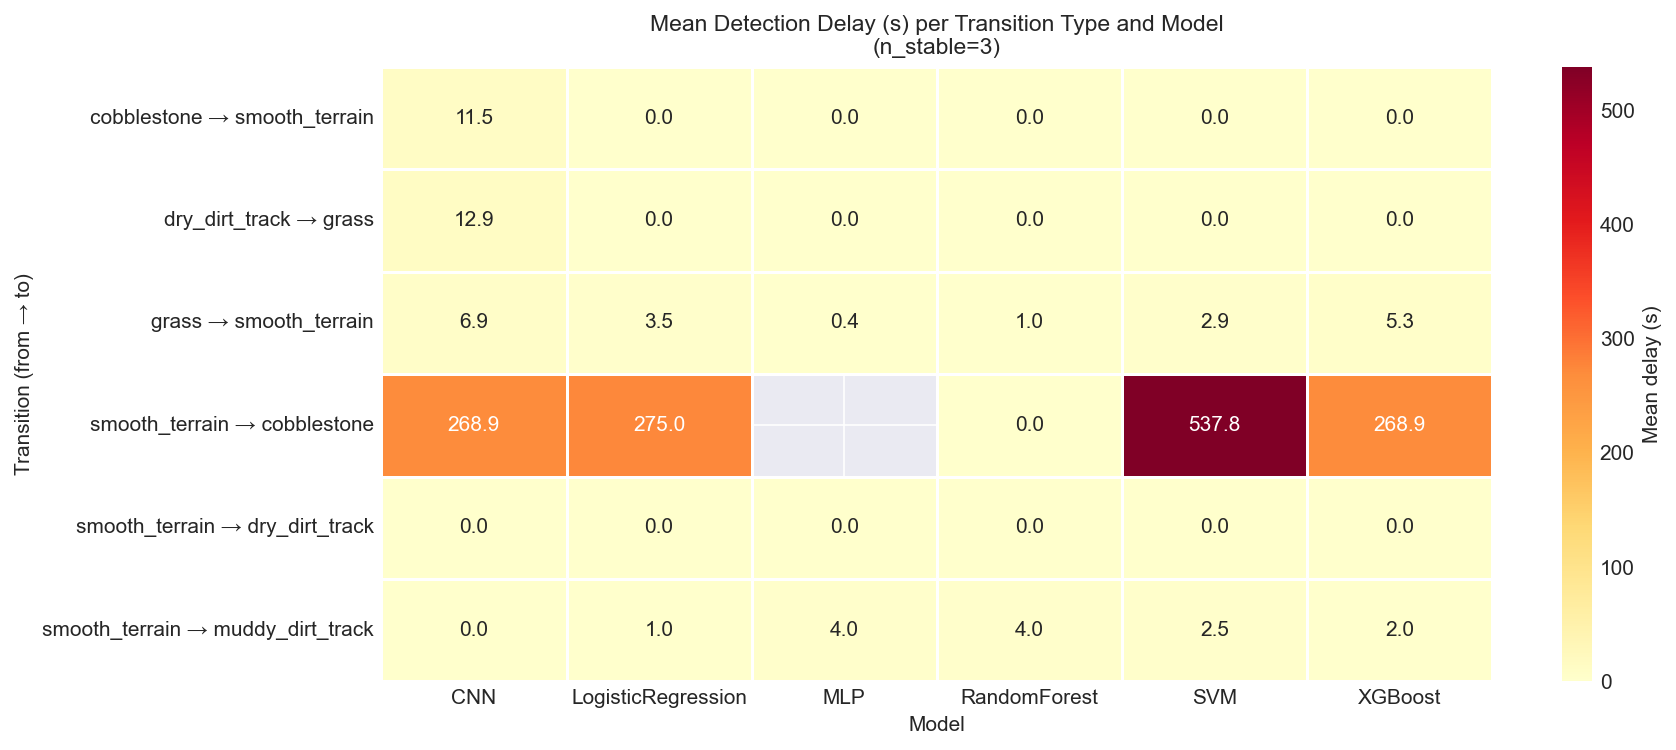

In [13]:
# Mean delay and detection rate per (from_label, to_label) pair, across all models
pair_df = (
    combined_transitions[combined_transitions["outcome"] == "detected"]
    .assign(transition_pair=lambda x: x["from_label"] + " → " + x["to_label"])
    .groupby(["transition_pair", "model"])["detection_delay_sec"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "mean_delay_s", "count": "n_detected"})
    .reset_index()
)

if not pair_df.empty:
    # Pivot for display
    pivot = pair_df.pivot(index="transition_pair", columns="model", values="mean_delay_s")
    fig, ax = plt.subplots(figsize=(12, max(3, len(pivot) * 0.6 + 1.5)), dpi=150)
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Mean delay (s)"},
    )
    ax.set_title(f"Mean Detection Delay (s) per Transition Type and Model\n(n_stable={N_STABLE})",
                 fontsize=11)
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel("Transition (from → to)", fontsize=10)
    fig.tight_layout()
    save_path = REPORTS_DIR / "transition_delay_heatmap.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
else:
    print("No detected transitions to plot.")

## 9. Conclusions and Thesis Interpretation

### 9.1 Detection Rate

> Updated from current notebook outputs (`summary_df` and `combined_transitions`).

Coverage is **not** 100% for all deep models in this run. The observed detection rates are:
- **100%**: XGBoost, LogisticRegression, CNN
- **91.7%**: SVM
- **83.3%**: RandomForest, MLP

So the main divide is:
- Some models detect all transitions but can include extreme late detections (XGBoost, LogisticRegression, CNN).
- Some models are faster on average but miss transitions (MLP, RandomForest, SVM).

### 9.2 Delay Structure and the 537-Second Outlier

A strong heavy-tail pattern remains. For XGBoost, LogisticRegression, CNN, and SVM, mean delay is dominated by a **537.8 s** event, while medians remain near zero (0.00-0.52 s).

> Interpretation: means are not representative for these models under rare long unstable epochs; medians and miss-rate should be reported alongside means.

### 9.3 MLP vs. CNN - Revised Interpretation

The previous claim that both deep models reached 100% detection is not valid for this executed run.

- **MLP**: 83.3% detection (10/12), mean delay 1.02 s, max delay 4.03 s.
- **CNN**: 100% detection (12/12), mean delay 49.74 s, median 0.00 s, max delay 537.8 s.

MLP missed **both** `smooth_terrain -> cobblestone` transitions (in `log_20260309_141435.414_partB` and `log_20260326_120021.508`), which is why that heatmap cell is NaN for MLP.

So, in this run:
- MLP is **more delay-consistent when it detects**, but has lower coverage.
- CNN has **full coverage**, but includes a severe long-delay tail.

### 9.4 Practical Implication for Robot Control

At 0.5-1.0 m/s, decision preference depends on control objective:

| Objective | Preferred family in this run | Why |
|---|---|---|
| Never miss transitions | XGBoost / LogisticRegression / CNN | 100% detection coverage |
| Keep typical delays short and stable | MLP (with caveat) | Lowest mean and max among non-outlier models, but misses 2 transitions |

A robust deployment strategy is to monitor both **coverage** and **tail latency** (e.g., p95/p99 delay), not just mean delay.

### 9.5 Sensitivity to `n_stable` (3 vs 5)

From the executed sensitivity table:
- At `n_stable=3`:
  - 100%: CNN, LogisticRegression, XGBoost
  - 91.7%: SVM
  - 83.3%: MLP, RandomForest
- At `n_stable=5`:
  - 91.7%: XGBoost
  - 83.3%: CNN
  - 75.0%: LogisticRegression, MLP, RandomForest, SVM

Thus, increasing stability generally reduces detection rate across models in this experiment, with XGBoost degrading the least from 3 to 5.

### 9.6 Transition Difficulty Hierarchy (Current Run)

From the per-pair delay table (detected-only means):
- **Easiest / immediate for most models**: `smooth_terrain -> dry_dirt_track` (0 s for all models).
- **Generally easy**: `cobblestone -> smooth_terrain`, `dry_dirt_track -> grass` (mostly 0 s; CNN around 11-13 s).
- **Moderate**: `grass -> smooth_terrain` (model-dependent, ~0.4-6.9 s).
- **Most problematic**: `smooth_terrain -> cobblestone` (misses for MLP in both instances, one miss for SVM and RF, and very large delays for several models).

### 9.7 Limitations

1. **Small transition count** (n=12 across 5 runs): conclusions are directional, not definitive.
2. **High sensitivity to single events**: one 537.8 s case strongly shifts mean-based rankings.
3. **Batch prediction setting**: online adaptation effects are not modeled.
4. **Single environment**: transfer to different terrain/weather contexts remains unverified in this transition protocol.
5. **No probability calibration / temporal smoothing policy search**: post-processing (calibration, hysteresis, sequential filtering) could change both miss-rate and tail delay substantially.